# Proyecto Final - Data Science Parte I  
## Análisis de Campañas de Marketing  

Dataset: Marketing Campaign Dataset  
Autor: Facundo López  
Fecha: 26/02/2026

En este trabajo se analiza un dataset de campañas de marketing de una empresa del sector retail con el objetivo de entender qué factores influyen en la respuesta de los clientes ante una campaña promocional. El conjunto de datos incluye información demográfica (edad, educación, estado civil), nivel de ingresos, composición del hogar, comportamiento de compra en distintas categorías de productos y la interacción previa con campañas.

El análisis parte de una pregunta central: qué características tienen los clientes que aceptan una campaña en comparación con los que no lo hacen. A partir de esto, se plantean hipótesis relacionadas con el nivel de ingresos, el gasto total, la cantidad de compras online y la presencia de hijos en el hogar. La idea es identificar patrones que permitan comprender mejor el comportamiento del consumidor y, potencialmente, mejorar la segmentación de futuras campañas.

Para responder estas preguntas se desarrollan visualizaciones univariadas, bivariadas y multivariadas, acompañadas de resúmenes estadísticos que permiten observar tendencias y relaciones entre variables. También se identifican valores perdidos y posibles anomalías que puedan afectar la interpretación de los resultados.

Los hallazgos preliminares muestran que los clientes con mayores ingresos y mayor gasto total tienden a responder más positivamente a las campañas. Sin embargo, no todas las variables analizadas presentan una relación clara, lo que demuestra que el comportamiento del consumidor no depende de un único factor sino de una combinación de variables económicas y conductuales.

##Pregunta Ancla para el análisis

---


¿Qué factores influyen en la probabilidad de que un cliente acepte una campaña de marketing?


##Hipótesis planteadas

---


h1: La mayoría de los clientes pertenecen a un segmento de ingresos medios, lo que sugiere que la empresa apunta a un público de clase media.

h2:Los clientes que realizaron compras más recientemente tienen mayor probabilidad de aceptar la campaña.

h3:Los clientes con mayores ingresos y compras recientes tienen mayor probabilidad de aceptar la campaña.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df  = pd.read_csv("https://raw.githubusercontent.com/faacu12/DataScience/refs/heads/main/marketing_campaign(1).csv",sep = ";")



##Valores perdidos

In [2]:

missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

Income    24
dtype: int64

Al ver que tenemos muchos "Nan" en la columna de ingresos, no podemos trabajar con esos datos... tenemos que reemplazarlos con algunos valores. Propongo reemplazarlos con la media de los ingresos

In [3]:
df["Income"] = df["Income"].fillna(df["Income"].median())

# Univariado

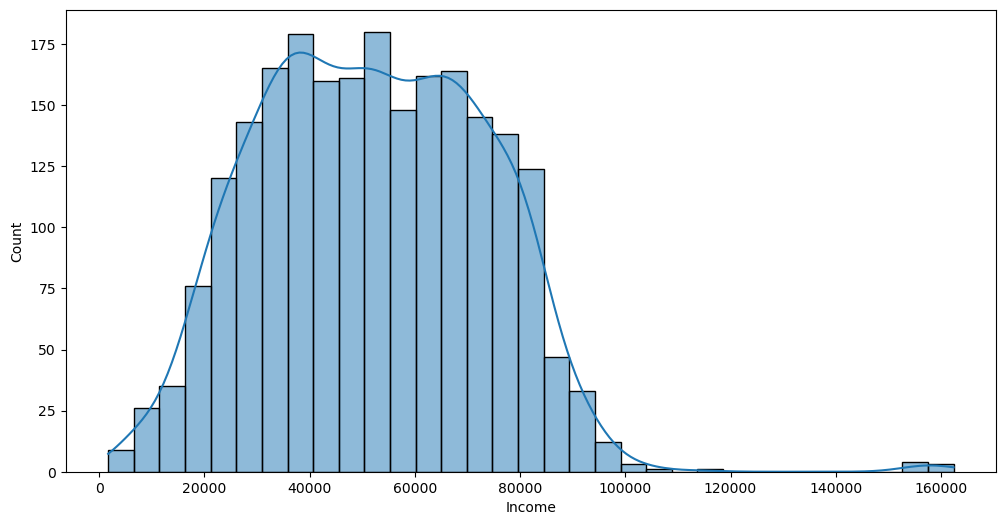

In [4]:
plt.figure(figsize=(12,6))

sns.histplot(df[df["Income"] < 200000]["Income"], kde = "True")
plt.show()

En base a la primera hipótesis, que sugería lo siguiente:
"La mayoría de los clientes pertenecen a un segmento de ingresos medios, lo que sugiere que la empresa apunta a un público de clase media"

Se propuso este gráfico, en donde vemos representado gráficamente que el pico de cantidad de clientes se encuentra ubicado en el sector de ingresos medios.

In [5]:
df["Income"].describe()

count      2240.000000
mean      52237.975446
std       25037.955891
min        1730.000000
25%       35538.750000
50%       51381.500000
75%       68289.750000
max      666666.000000
Name: Income, dtype: float64

Podemos ver que la media de ingresos, siendo que tenemos registros de 2240 clientes, es alrededor de 50k. Lo que nos deja en claro que la mayoría ronda los ingresos medios

# Bivariado


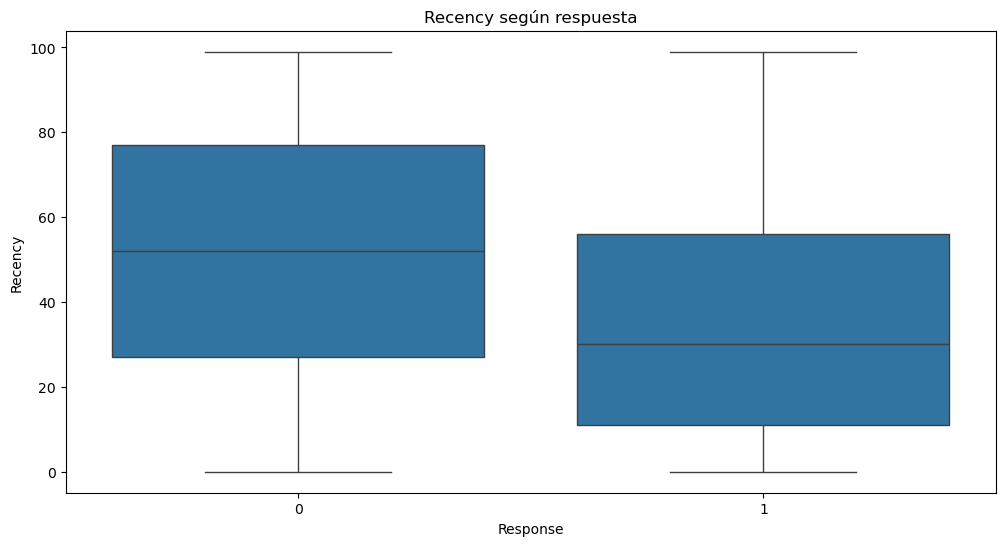

In [6]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x="Response",
    y="Recency",
    data=df
)

plt.title("Recency según respuesta")
plt.show()

En este gráfico vemos claramente la respuesta a la hipótesis 2, que sugería:
"Los clientes que realizaron compras más recientemente tienen mayor probabilidad de aceptar la campaña"

Al notar que las aceptaciones se encuentran concentradas en bloque en la parte inferior del gráfico, confirmamos que está relacionado con una menor recencia en compras.

In [7]:
df.groupby("Response")["Recency"].agg(["count","mean","median","min","max"])

,count,mean,median,min,max
Response,,,,,
0,1906,51.514690,52.0,0,99
1,334,35.383234,30.0,0,99


En este análisis numérico vemos que la "1 response", que muestra las aceptaciones, tienen como media una menor recencia. Entonces, confirmamos que a menor tiempo que pasó desde la última compra de un cliente, mayor probabilidad de respuesta positiva a la campaña existe.

# Multivariada

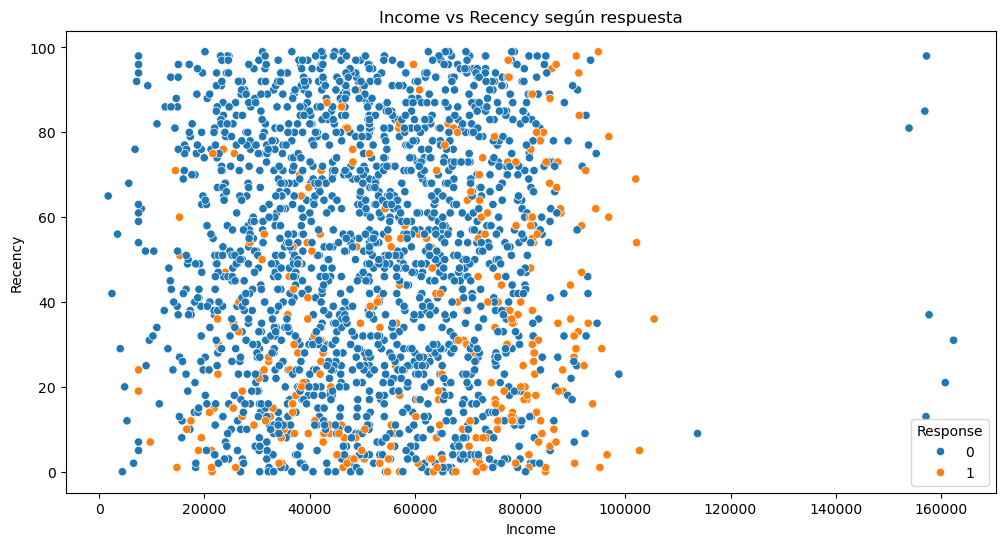

In [8]:
plt.figure(figsize=(12,6))
sns.scatterplot(
    x="Income",
    y="Recency",
    hue="Response",
    data=df[df["Income"] < 200000]
)

plt.title("Income vs Recency según respuesta")
plt.show()

 Este gráfico fue propuesto para responder o analizar en base a la tercera hipótesis, la cual sugería:
 "Los clientes con mayores ingresos y compras recientes tienen mayor probabilidad de aceptar la campaña"

 Vemos representada gráficamente la respuesta, debido a que notamos con claridad que esta hipótesis es acertada. A mayor ingreso (desplazamiento horizontal) vemos mayor cantidad de puntos naranjas.

 *Pero es más intersante notar que esos puntos se concentran en la parte inferior del gráfico, viendo la relación entre las dos variables*.

 En resumen, a mas ingreso y menos recencia, mayor probabilidad de aceptar la campaña

In [9]:
df.groupby("Response")[["Income","Recency"]].agg(["mean","median"])

Income             Recency       
                  mean   median       mean median
Response                                         
0         50845.677597  50567.0  51.514690   52.0
1         60183.244012  64044.0  35.383234   30.0

Este análisis numérico, muy parecido al anterior, nos muestra la relación numérica entre las variables. Vemos como las "1 response" tienen media mas alta de ingresos, y menor de recencia.